### Imports and some basic color setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# This whole aesthtic section is AI generated, propmpted it (Claude sonnet) to make the plot look fire and dark themed and it did a prety good job.
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#e0e0e0',
    'grid.color': '#2e2e2e',
    'grid.linestyle': '--',
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444',
    'font.family': 'DejaVu Sans',
})

PALETTE   = ['#4fc3f7', '#ff8a65', '#a5d6a7', '#ce93d8']
FIRE_COLORS = {'Low':'#4fc3f7', 'Moderate':'#ffcc02', 'High':'#ff8a65', 'Extreme':'#e53935'}
TARGET_ORDER = ['Low', 'Moderate', 'High', 'Extreme']

In [9]:
# Data Loading 
train_df=pd.read_csv('wildfire_cls_train_full.csv')
# We can import the test set later when we are ready to clear it for data leakage and formatting it similar to the train set after data preprocessing and feature engineering.

print(train_df.head(10))
print('\n')
print(f'Shape of the training data: {train_df.shape}')

   latitude  longitude    acq_date  acq_time  year  month  season daynight  \
0  -22.1967   -61.5275  2024-08-12      1838  2024    NaN  Winter        D   
1   64.2205   -53.4116  2024-07-11       424  2024    7.0  Summer        N   
2   38.6810     9.5739  2024-06-18       546  2024    6.0  Summer        N   
3   68.1959   -90.3475  2024-08-26      2240  2024    8.0  Summer        N   
4    0.6527   118.6227  2025-08-09      2301  2025    8.0  Summer        N   
5   33.4589    71.9806  2025-11-01      1536  2025   11.0  Autumn        D   
6   28.4294    63.9391  2024-05-30       530  2024    5.0  Spring        N   
7  -29.2148   122.2033  2024-02-19      1840  2024    NaN  Summer        D   
8   25.4646  -136.8306  2024-09-09      1823  2024    9.0  Autumn        D   
9  -17.6045   123.0066  2024-02-27      2205  2024    2.0  Summer        N   

           region     country      fire_type  satellite instrument  \
0   South_America        Peru  Deforestation  Suomi-NPP      VIIRS   
1

In [10]:
# always easy to just do .info()
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        4340 non-null   float64
 1   longitude       4340 non-null   float64
 2   acq_date        4340 non-null   object 
 3   acq_time        4340 non-null   int64  
 4   year            4340 non-null   int64  
 5   month           3924 non-null   float64
 6   season          4340 non-null   object 
 7   daynight        4340 non-null   object 
 8   region          4340 non-null   object 
 9   country         4340 non-null   object 
 10  fire_type       4340 non-null   object 
 11  satellite       4340 non-null   object 
 12  instrument      4340 non-null   object 
 13  brightness_k    4013 non-null   float64
 14  confidence      4340 non-null   object 
 15  temp_max_c      4340 non-null   float64
 16  wind_max_kmh    4133 non-null   float64
 17  precip_mm       4340 non-null   f

 Upon quick overview we csn check that there is lot of missing values in some of the features like "month", "brightness_k" etc., and they are all of varying data types. lets first check how the values in the feature "acq_date" are coz often its the one feature that has most issues

 

In [13]:
print(train_df['acq_date'])

0       2024-08-12
1       2024-07-11
2       2024-06-18
3       2024-08-26
4       2025-08-09
           ...    
4335    2024-06-19
4336    2025-04-17
4337    2024-09-13
4338    2024-12-05
4339    2025-05-09
Name: acq_date, Length: 4340, dtype: object


In [14]:
print(train_df['month'])

0        NaN
1        7.0
2        6.0
3        8.0
4        8.0
        ... 
4335     6.0
4336     4.0
4337     9.0
4338    12.0
4339     5.0
Name: month, Length: 4340, dtype: float64


In [15]:
# its seems like the "month" feature was feature engineered from the "acq_date" feature with so many missing values.

Since the data for wildfires is mostly acquired from datasets, there is a good chacne many of the features are correlated for example "pressure",could be correlated to "humidity" and the whole reason those features are missing could be beacuase of failure of the sensor. anyway before we start dealing with missing values and feature engineering and data preperation le's see the data summary and some important overview like the percentage of missing rows per feature

In [17]:
overview =pd.DataFrame({
  'dtype':        train_df.dtypes,
    'nulls':        train_df.isnull().sum(),
    'null_%':       (train_df.isnull().mean()*100).round(2),
    'n_unique':     train_df.nunique(),
    'sample':       train_df.iloc[0]
})

print(overview)

                  dtype  nulls  null_%  n_unique         sample
latitude        float64      0    0.00      4329       -22.1967
longitude       float64      0    0.00      4335       -61.5275
acq_date         object      0    0.00       709     2024-08-12
acq_time          int64      0    0.00      1375           1838
year              int64      0    0.00         2           2024
month           float64    416    9.59        12            NaN
season           object      0    0.00         4         Winter
daynight         object      0    0.00         2              D
region           object      0    0.00         7  South_America
country          object      0    0.00        35           Peru
fire_type        object      0    0.00        10  Deforestation
satellite        object      0    0.00         4      Suomi-NPP
instrument       object      0    0.00         2          VIIRS
brightness_k    float64    327    7.53      2949         360.26
confidence       object      0    0.00  

In [18]:
print("NUMERICAL SUMMARY")
train_df.describe().T.style.background_gradient(cmap='YlOrRd', axis=1)

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
latitude,4340.000000,9.821703,24.321271,-42.988300,-8.611625,10.268500,29.011025,69.930900
longitude,4340.000000,29.430626,78.842700,-167.990600,-40.980600,34.833700,95.166775,153.754900
acq_time,4340.000000,1177.046774,683.844117,0.000000,602.000000,1208.000000,1752.000000,2359.000000
year,4340.000000,2024.501843,0.500054,2024.000000,2024.000000,2025.000000,2025.000000,2025.000000
month,3924.000000,7.240316,2.791615,1.000000,5.000000,8.000000,9.000000,12.000000
brightness_k,4013.000000,336.677742,18.539217,290.000000,324.860000,335.530000,346.990000,503.710000
temp_max_c,4340.000000,35.082627,5.821218,17.700000,31.000000,35.100000,39.125000,54.100000
wind_max_kmh,4133.000000,17.508033,17.051980,0.000000,5.100000,12.400000,24.000000,130.700000
precip_mm,4340.000000,2.597111,3.062512,0.000000,0.600000,1.540000,3.370000,23.690000
humidity_pct,4340.000000,37.924378,18.731153,5.000000,24.200000,36.200000,50.500000,95.000000


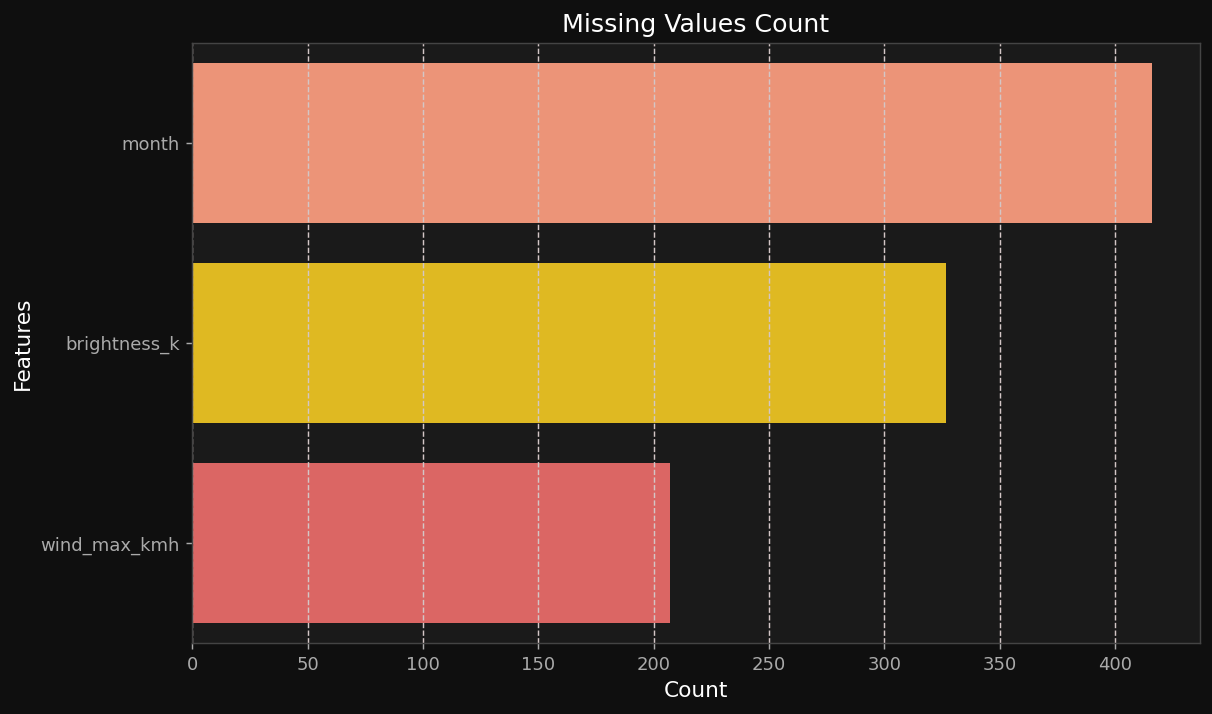

<Figure size 832x624 with 0 Axes>

In [26]:
missing_values =train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.values, y=missing_values.index, palette=['#ff8a65', '#ffcc02', '#ef5350'])
plt.title('Missing Values Count', fontsize=14, color='white')
plt.xlabel('Count', fontsize=12, color='white')
plt.ylabel('Features', fontsize=12, color='white')
plt.grid(axis='x', color="#d3c6c6", linestyle='--')
plt.style.background_color="#F0E4E400"
plt.show()
plt.tight_layout()

## 2. Checking correleation bwtween missing value features

earlier we talked about how the some features could be correlated and if they are indeed correlated then dealing with missing values could involve considering all the corelated features together and not individually, this is true for imputation or some feature selection. 

In [27]:
miss_combo = train_df[['month','brightness_k','wind_max_kmh']].isnull()
print(miss_combo.corr().round(3))

              month  brightness_k  wind_max_kmh
month         1.000        -0.019         0.019
brightness_k -0.019         1.000         0.039
wind_max_kmh  0.019         0.039         1.000


Seems like they are indeed not corelated 

## 3. Imputation rationale 

### 3.1 imputing the unreliable month feature.

for this we could simply extract the month variable from "acq_date" and replace all the values in "month" feature with the extracted value

In [29]:
# always better to work on a duplicated dataset than original,
df=train_df.copy()
# we saw that the feature "acq_date" is a Object data type and to extract the "month", "year" and "day" features from it we hav eto convert it inot a datatie vatiable.

df['acq_date'] =pd.to_datetime(df['acq_date'],errors='coerce')
# now we can just replace the whole month feature with the onth extracted from "acq_date"ArithmeticError
df['month'] =df['acq_date'].dt.month

In [30]:
df['month'].isnull().sum()

np.int64(0)

In [31]:
df['month'].dtype

dtype('int32')

In [32]:
# You know what if there are missing value it could also be true that the "year" and "day" feature could also be wrong ! so lets just replace those as welll with the extracted values from 'acq_date"

df['year']=df['acq_date'].dt.year
df['day']=df['acq_date'].dt.day



In [33]:
df.columns

Index(['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month',
       'season', 'daynight', 'region', 'country', 'fire_type', 'satellite',
       'instrument', 'brightness_k', 'confidence', 'temp_max_c',
       'wind_max_kmh', 'precip_mm', 'humidity_pct', 'fire_intensity', 'day'],
      dtype='object')

Alright from what's dpne so far we extracted new features from 'acq_date" atleast some of them , since we are going for Decision Trees and SVM, they cant really learn from complex temporal features like "axq_date" and "acq_time", so we could also extract features from "acq_time" , lets do that after we finis with imputing the missing values for rest of the features 

reference : https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/